In [1]:
# ============================================================
#  1주차 표 VLM 칸 채우기 (Google Colab, 무료 T4)
#  - Object abstraction = photo vs sketch 분류 정확도 격차
#  - failure case 수집 ("VLM 영향" 열 / 산출물)
#
#  사용법: 아래 블록을 Colab 셀에 하나씩 복사해 실행.
#  런타임 > 런타임 유형 변경 > GPU(T4) 선택 필수.
# ============================================================


# ====== CELL 1 : 패키지 설치 ======
# Qwen2.5-VL은 transformers>=4.49면 됨. (Qwen3-VL은 >=4.57, T4엔 8B 무거워 비권장)
!pip install -q "transformers>=4.49" accelerate qwen-vl-utils pillow


# ====== CELL 2 : 데이터 업로드 & 압축해제 ======
# 로컬의 data_samples.zip 을 선택해 업로드
from google.colab import files
up = files.upload()                 # data_samples.zip 선택
!unzip -o -q data_samples.zip
!echo "--- 폴더별 장수 ---"; for d in data_samples/*/; do echo "$d $(ls $d | wc -l)"; done
# (대안) 구글드라이브 사용 시:
# from google.colab import drive; drive.mount('/content/drive')
# !cp /content/drive/MyDrive/data_samples.zip . && unzip -o -q data_samples.zip


# ====== CELL 3 : 모델 로드 (T4에 맞는 3B) ======
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"     # T4 16GB에 안정적으로 적재
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="auto")
processor = AutoProcessor.from_pretrained(MODEL)
print("loaded:", MODEL)

def ask(image_path, prompt, max_new=24):
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": image_path},
        {"type": "text",  "text": prompt}]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    imgs, vids = process_vision_info(msgs)
    inputs = processor(text=[text], images=imgs, videos=vids,
                       padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out)]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


# ====== CELL 4 : 분류 정확도 측정 (abstraction 격차) ======
import glob, os, re, json

# 파일명 "cat__n0212...jpg" -> gt="cat"
def gt_of(f): return os.path.basename(f).split("__")[0].lower()

# 정답 매칭(관대): 동의어/복수형 흡수
SYN = {"pear": ["pear"], "apple": ["apple"], "cat": ["cat", "kitten", "feline"],
       "cow": ["cow", "cattle", "bull", "ox"], "horse": ["horse", "pony"],
       "duck": ["duck", "duckling"], "penguin": ["penguin"], "pig": ["pig", "piglet", "hog"],
       "chair": ["chair", "seat", "stool"], "hat": ["hat", "cap"], "lizard": ["lizard", "reptile"]}
def is_correct(pred, gt):
    p = re.sub(r"[^a-z ]", " ", pred.lower())
    words = SYN.get(gt, [gt])
    return any(w in p for w in words) or gt in p

PROMPT = "What is the main object in this image? Answer with ONE common English noun only."

def run_group(folder):
    res = []
    files = sorted(f for f in glob.glob(folder + "/*")
                   if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")))
    for i, f in enumerate(files):
        try:
            ans = ask(f, PROMPT)
        except Exception as e:
            ans = f"ERR:{e}"
        ok = is_correct(ans, gt_of(f))
        res.append({"file": os.path.basename(f), "gt": gt_of(f), "pred": ans, "correct": ok})
        if (i + 1) % 20 == 0:
            print(f"  {folder}: {i+1}/{len(files)}")
    acc = sum(r["correct"] for r in res) / max(len(res), 1)
    return res, acc

print(">> photo 분류 중..."); photo_res, photo_acc = run_group("data_samples/sketchy_photo")
print(">> sketch 분류 중..."); sketch_res, sketch_acc = run_group("data_samples/sketchy_sketch")

print("\n===== Object abstraction (분류 정확도) =====")
print(f"photo  accuracy : {photo_acc:.3f}")
print(f"sketch accuracy : {sketch_acc:.3f}")
print(f"ABSTRACTION GAP : {photo_acc - sketch_acc:+.3f}  (사진 대비 스케치 정확도 하락폭)")


# ====== CELL 5 : failure case 수집 ("VLM 영향" 열 / 산출물) ======
fails = [r for r in sketch_res if not r["correct"]]
print(f"sketch 오인식: {len(fails)}/{len(sketch_res)}건")
print("\n--- 대표 failure 20건 (gt -> 모델 답) ---")
for r in fails[:20]:
    print(f"  [{r['gt']:8s}] -> '{r['pred']}'   ({r['file']})")

# 카테고리별 정확도(어떤 객체가 스케치에서 더 안 잡히나)
from collections import defaultdict
bycat = defaultdict(lambda: [0, 0])
for r in sketch_res:
    bycat[r["gt"]][0] += r["correct"]; bycat[r["gt"]][1] += 1
print("\n--- 카테고리별 sketch 정확도 ---")
for c, (ok, tot) in sorted(bycat.items()):
    print(f"  {c:8s}: {ok}/{tot} = {ok/tot:.2f}")


# ====== CELL 6 : (선택) captioning 샘플 — task 동작 확인 + 산출물 ======
CAP_PROMPT = "Describe this drawing in one sentence: object, line quality, completeness."
print("--- 캡션 샘플 5건 ---")
for f in sorted(glob.glob("data_samples/sketchy_sketch/*"))[:5]:
    print(f"[{gt_of(f)}] {ask(f, CAP_PROMPT, max_new=60)}")


# ====== CELL 7 : 결과 저장 & 다운로드 ======
summary = {
    "model": MODEL,
    "photo_acc": photo_acc, "sketch_acc": sketch_acc,
    "abstraction_gap": photo_acc - sketch_acc,
    "sketch_fail_rate": len(fails) / max(len(sketch_res), 1),
}
with open("vlm_table_results.json", "w", encoding="utf-8") as f:
    json.dump({"summary": summary, "photo": photo_res, "sketch": sketch_res},
              f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))
from google.colab import files as _f
_f.download("vlm_table_results.json")     # 로컬로 받아서 CV 결과와 합치기


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 50.1 MB/s eta 0:00:00


Saving data_samples.zip to data_samples.zip
--- 폴더별 장수 ---
data_samples/ai_hub_child/ 100
data_samples/coco/ 100
data_samples/sketchy_photo/ 93
data_samples/sketchyscene/ 100
data_samples/sketchy_sketch/ 99


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

loaded: Qwen/Qwen2.5-VL-3B-Instruct
>> photo 분류 중...
  data_samples/sketchy_photo: 20/93
  data_samples/sketchy_photo: 40/93
  data_samples/sketchy_photo: 60/93
  data_samples/sketchy_photo: 80/93
>> sketch 분류 중...
  data_samples/sketchy_sketch: 20/99
  data_samples/sketchy_sketch: 40/99
  data_samples/sketchy_sketch: 60/99
  data_samples/sketchy_sketch: 80/99

===== Object abstraction (분류 정확도) =====
photo  accuracy : 0.871
sketch accuracy : 0.667
ABSTRACTION GAP : +0.204  (사진 대비 스케치 정확도 하락폭)
sketch 오인식: 33/99건

--- 대표 failure 20건 (gt -> 모델 답) ---
  [apple   ] -> 'Satellite dish'   (apple__n07739125_12041-4.jpg)
  [apple   ] -> 'Rock'   (apple__n07739125_12353-2.jpg)
  [chair   ] -> 'Tooth'   (chair__n03001627_3353-2.jpg)
  [chair   ] -> 'Finger'   (chair__n03001627_5486-3.jpg)
  [cow     ] -> 'Horse'   (cow__n01887787_10853-4.jpg)
  [cow     ] -> 'Goat'   (cow__n01887787_12810-7.jpg)
  [cow     ] -> 'Dog'   (cow__n01887787_700-2.jpg)
  [cow     ] -> 'Face'   (cow__n01887787_9022-5.jpg

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
#  1주차 산출물: VLM 4대 task 실습 결과
#  (Captioning / VQA / Classification / Retrieval)
#
#  런타임: GPU(T4)
# ============================================================


# ====== CELL 0 : (가드) 모델/데이터 준비 — 이미 있으면 그냥 통과 ======
import os, glob, re, json, torch

def gt_of(f):  # "cat__n0212...jpg" -> "cat"
    return os.path.basename(f).split("__")[0].lower()

if "ask" not in globals():
    print("ask() 없음 -> Qwen2.5-VL 재로드")
    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
    from qwen_vl_utils import process_vision_info
    MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL, torch_dtype=torch.float16, device_map="auto")
    processor = AutoProcessor.from_pretrained(MODEL)
    def ask(image_path, prompt, max_new=48):
        msgs = [{"role": "user", "content": [
            {"type": "image", "image": image_path}, {"type": "text", "text": prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        imgs, vids = process_vision_info(msgs)
        inp = processor(text=[text], images=imgs, videos=vids,
                        padding=True, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=max_new, do_sample=False)
        tr = [o[len(i):] for i, o in zip(inp.input_ids, out)]
        return processor.batch_decode(tr, skip_special_tokens=True)[0].strip()

assert glob.glob("data_samples/sketchy_sketch/*"), "data_samples 없음 -> zip 업로드/해제 먼저"
SKETCHES = sorted(f for f in glob.glob("data_samples/sketchy_sketch/*")
                  if f.lower().endswith((".jpg", ".jpeg", ".png")))
CATS = sorted(set(gt_of(f) for f in SKETCHES))
print(f"sketches={len(SKETCHES)}, categories={CATS}")


# ====== CELL 1 : TASK 1 — Captioning (스케치 설명 생성) ======
CAP_PROMPT = ("Describe this hand-drawn sketch in one sentence. "
              "Mention: the main object, line quality, and whether it looks complete.")
cap_results = []
for i, f in enumerate(SKETCHES):
    cap = ask(f, CAP_PROMPT, max_new=60)
    cap_results.append({"file": os.path.basename(f), "gt": gt_of(f), "caption": cap})
    if i < 8:
        print(f"[{gt_of(f):8s}] {cap}")
    if (i + 1) % 25 == 0: print(f"  captioning {i+1}/{len(SKETCHES)}")
json.dump(cap_results, open("task1_captioning.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
print(f"\n캡션 {len(cap_results)}건 저장 -> task1_captioning.json")


# ====== CELL 2 : TASK 2 — VQA (질문-답) ======
VQA_QUESTIONS = [
    ("animal",  "Is the main object an animal? Answer only 'yes' or 'no'."),
    ("count",   "How many separate objects are drawn? Answer with a single integer."),
    ("color",   "Is this drawing in color or black-and-white? Answer 'color' or 'bw'."),
]
SAMPLE = SKETCHES[::max(1, len(SKETCHES)//20)][:20]   # 20장 샘플
vqa_results = []
ANIMALS = {"cat", "cow", "horse", "duck", "penguin", "pig", "lizard"}
for f in SAMPLE:
    row = {"file": os.path.basename(f), "gt": gt_of(f)}
    for key, q in VQA_QUESTIONS:
        row[key] = ask(f, q, max_new=12)
    vqa_results.append(row)
    exp_animal = "yes" if gt_of(f) in ANIMALS else "no"
    print(f"[{row['gt']:8s}] animal={row['animal']:>4s}(정답 {exp_animal}) | count={row['count']:>3s} | color={row['color']}")
json.dump(vqa_results, open("task2_vqa.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
# 'animal' 질문 정확도(우리가 카테고리로 정답을 알 수 있음)
acc_animal = sum(("yes" in r["animal"].lower()) == (r["gt"] in ANIMALS) for r in vqa_results) / len(vqa_results)
print(f"\nVQA 'animal' 정확도: {acc_animal:.2f}  (저장: task2_vqa.json)")


# ====== CELL 3 : TASK 3 — Classification (라벨로 정답 비교) ======
# QuickDraw 미보유 -> 라벨 보유한 Sketchy 스케치로 closed-set 분류.
# (QuickDraw 쓰려면 SKETCHES/CATS만 그 데이터로 교체하면 됨)
opt = ", ".join(CATS)
CLS_PROMPT = f"Classify the object in this sketch. Choose exactly ONE word from: {opt}. Answer with only that word."
cls_results, correct = [], 0
for i, f in enumerate(SKETCHES):
    pred = ask(f, CLS_PROMPT, max_new=8)
    pl = re.sub(r"[^a-z ]", " ", pred.lower())
    hit = gt_of(f) in pl
    correct += hit
    cls_results.append({"file": os.path.basename(f), "gt": gt_of(f), "pred": pred, "correct": hit})
    if (i + 1) % 25 == 0: print(f"  classification {i+1}/{len(SKETCHES)}")
cls_acc = correct / len(SKETCHES)
print(f"\nClassification accuracy(closed-set, sketch): {cls_acc:.3f}")
# 카테고리별
from collections import defaultdict
bc = defaultdict(lambda: [0, 0])
for r in cls_results: bc[r["gt"]][0] += r["correct"]; bc[r["gt"]][1] += 1
for c, (o, t) in sorted(bc.items()): print(f"  {c:8s}: {o}/{t} = {o/t:.2f}")
json.dump(cls_results, open("task3_classification.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)


sketches=99, categories=['apple', 'cat', 'chair', 'cow', 'duck', 'hat', 'horse', 'lizard', 'pear', 'penguin', 'pig']
[apple   ] The hand-drawn sketch depicts an incomplete apple with a stem, drawn with simple, uneven lines that suggest a quick, rough sketch rather than a detailed illustration.
[apple   ] The hand-drawn sketch depicts a simple, circular shape with a small, abstract figure inside, resembling a keyhole or a small house, rendered with basic lines of varying thickness. The overall appearance is incomplete as it lacks details and context.
[apple   ] The hand-drawn sketch depicts an apple with a simple, smooth line quality, but it does not appear to be completely drawn as there is a small gap at the bottom where the apple would typically end.
[apple   ] The hand-drawn sketch depicts a simple, abstract shape resembling a rock or a piece of stone, with uneven edges and a rough texture, drawn with a single continuous line that appears to be slightly wobbly, giving it a somewhat 

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [6]:
# ====== CELL 4 : TASK 4 — Retrieval (SigLIP 2 임베딩) ======
!pip install -q -U "transformers>=4.49"
from transformers import AutoProcessor as SPProc, AutoModel
from PIL import Image
import numpy as np

SIG = "google/siglip2-base-patch16-224"
sp = SPProc.from_pretrained(SIG)
sm = AutoModel.from_pretrained(SIG, torch_dtype=torch.float16).to("cuda").eval()

def _feat(out):
    # 버전에 따라 텐서/출력객체 둘 다 대응 (SigLIP은 pooler_output == 정렬 임베딩)
    if torch.is_tensor(out):
        return out
    for attr in ("image_embeds", "text_embeds", "pooler_output"):
        v = getattr(out, attr, None)
        if v is not None:
            return v
    raise RuntimeError(f"임베딩 못 찾음: {type(out)}")

@torch.no_grad()
def embed_images(paths, bs=16):
    embs = []
    for i in range(0, len(paths), bs):
        ims = [Image.open(p).convert("RGB") for p in paths[i:i+bs]]
        inp = sp(images=ims, return_tensors="pt").to("cuda")
        e = _feat(sm.get_image_features(**inp))
        embs.append((e / e.norm(dim=-1, keepdim=True)).float().cpu())
    return torch.cat(embs)

@torch.no_grad()
def embed_texts(texts):
    inp = sp(text=texts, padding="max_length", return_tensors="pt").to("cuda")
    e = _feat(sm.get_text_features(**inp))
    return (e / e.norm(dim=-1, keepdim=True)).float().cpu()

labels = np.array([gt_of(f) for f in SKETCHES])
img_emb = embed_images(SKETCHES)
txt_emb = embed_texts([f"a sketch of a {c}" for c in CATS])

# 두 방향 공통 평가: R@1, R@5, mAP (정답 여러 개인 카테고리 검색이므로 mAP가 정석)
def eval_retrieval(sim, relevant, ks=(1, 5)):
    sim = sim.cpu().numpy(); order = (-sim).argsort(axis=1)   # 유사도 내림차순 랭킹
    res = {f"R@{k}": 0.0 for k in ks}; ap_sum = 0.0; valid = 0
    for q in range(sim.shape[0]):
        r = relevant[q][order[q]]                            # 랭킹 순서대로 정답여부
        if r.sum() == 0: continue
        valid += 1
        for k in ks:
            res[f"R@{k}"] += 1.0 if r[:k].any() else 0.0     # top-k 안에 정답 존재(hit-rate)
        cum = np.cumsum(r); prec = cum / (np.arange(len(r)) + 1)
        ap_sum += (prec * r).sum() / r.sum()                 # average precision
    for k in ks: res[f"R@{k}"] /= valid
    res["mAP"] = ap_sum / valid
    return {k: round(float(v), 3) for k, v in res.items()}

# (a) text -> image : 쿼리=카테고리 텍스트, 정답=그 카테고리 이미지
rel_t2i = np.array([[labels[j] == CATS[qi] for j in range(len(labels))] for qi in range(len(CATS))])
t2i = eval_retrieval(txt_emb @ img_emb.T, rel_t2i)
print("text->image :", t2i)

# (b) image -> image : 쿼리=각 스케치, 정답=같은 카테고리(자기 제외)
isim = img_emb @ img_emb.T; isim.fill_diagonal_(-1e4)
rel_i2i = (labels[:, None] == labels[None, :]); np.fill_diagonal(rel_i2i, False)
i2i = eval_retrieval(isim, rel_i2i)
print("image->image:", i2i)

# 샘플: text 쿼리별 top-5가 뭐였는지 (정성 확인용)
sim = txt_emb @ img_emb.T
for ci, c in enumerate(CATS):
    top5 = sim[ci].topk(5).indices.tolist()
    print(f"  '{c:8s}' top5 ->", [labels[j] for j in top5])

json.dump({"text2img": t2i, "img2img": i2i},
          open("task4_retrieval.json", "w", encoding="utf-8"), indent=2)


# ====== CELL 5 : 4대 task 종합 요약 (산출물) ======
summary = {
    "task1_captioning": f"{len(cap_results)} captions (task1_captioning.json)",
    "task2_vqa_animal_acc": round(acc_animal, 3),
    "task3_classification_acc": round(cls_acc, 3),
    "task4_text2img": t2i,    # {R@1, R@5, mAP}
    "task4_img2img": i2i,     # {R@1, R@5, mAP}
}
print(json.dumps(summary, ensure_ascii=False, indent=2))
with open("vlm_tasks_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
from google.colab import files
for fn in ["task1_captioning.json", "task2_vqa.json", "task3_classification.json",
           "task4_retrieval.json", "vlm_tasks_summary.json"]:
    files.download(fn)


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

text->image : {'R@1': 1.0, 'R@5': 1.0, 'mAP': 0.982}
image->image: {'R@1': 0.888, 'R@5': 0.98, 'mAP': 0.818}
  'apple   ' top5 -> [np.str_('apple'), np.str_('apple'), np.str_('apple'), np.str_('apple'), np.str_('pear')]
  'cat     ' top5 -> [np.str_('cat'), np.str_('cow'), np.str_('pig'), np.str_('hat'), np.str_('horse')]
  'chair   ' top5 -> [np.str_('chair'), np.str_('chair'), np.str_('chair'), np.str_('chair'), np.str_('chair')]
  'cow     ' top5 -> [np.str_('cow'), np.str_('cow'), np.str_('cow'), np.str_('cow'), np.str_('cow')]
  'duck    ' top5 -> [np.str_('duck'), np.str_('duck'), np.str_('duck'), np.str_('duck'), np.str_('duck')]
  'hat     ' top5 -> [np.str_('hat'), np.str_('hat'), np.str_('hat'), np.str_('hat'), np.str_('hat')]
  'horse   ' top5 -> [np.str_('horse'), np.str_('horse'), np.str_('horse'), np.str_('horse'), np.str_('horse')]
  'lizard  ' top5 -> [np.str_('lizard'), np.str_('lizard'), np.str_('lizard'), np.str_('lizard'), np.str_('lizard')]
  'pear    ' top5 -> [np

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

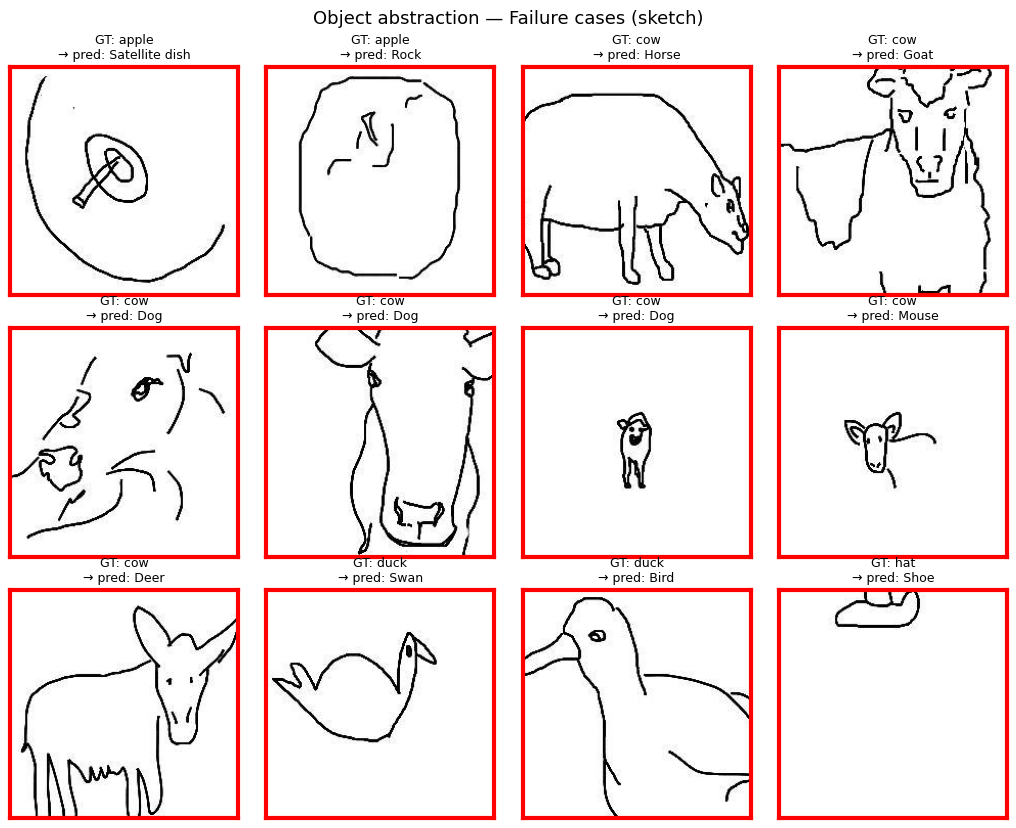

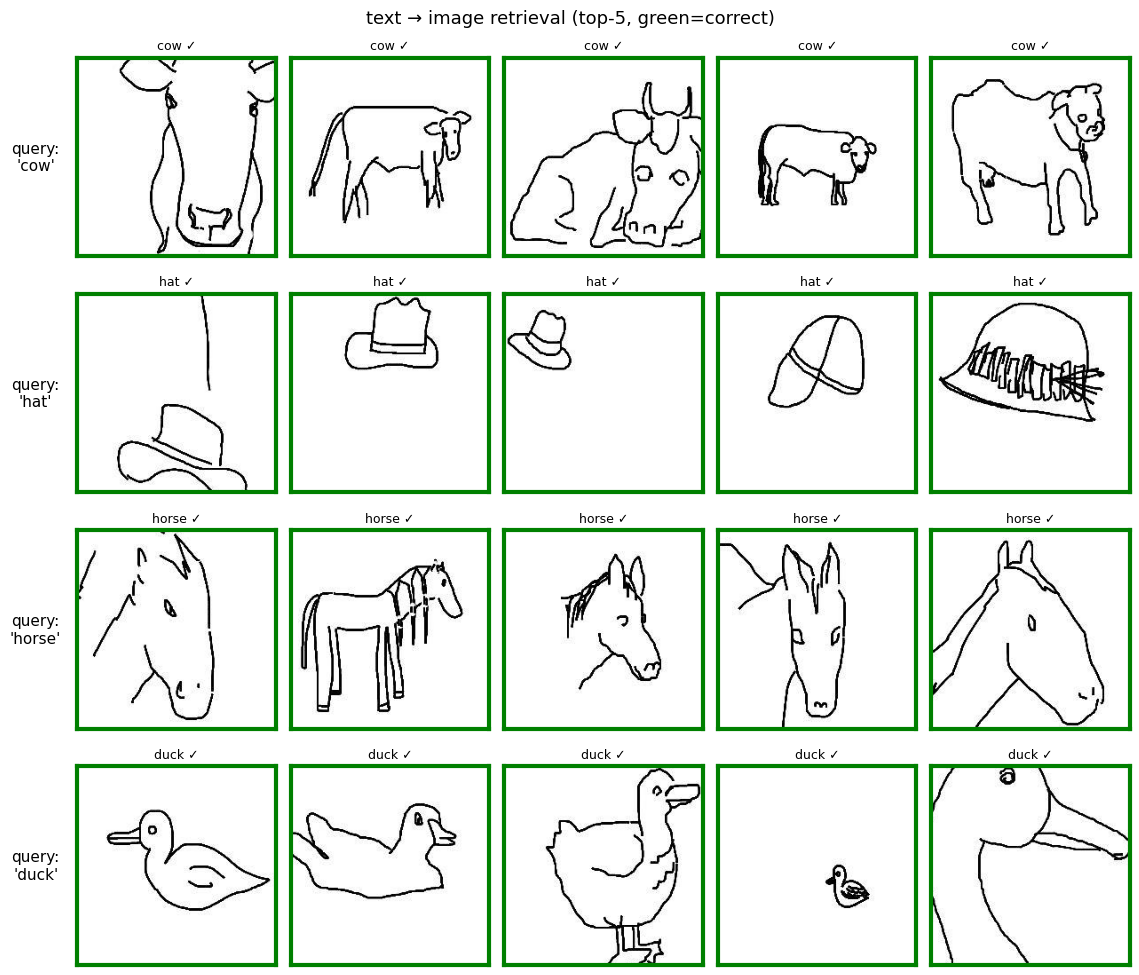

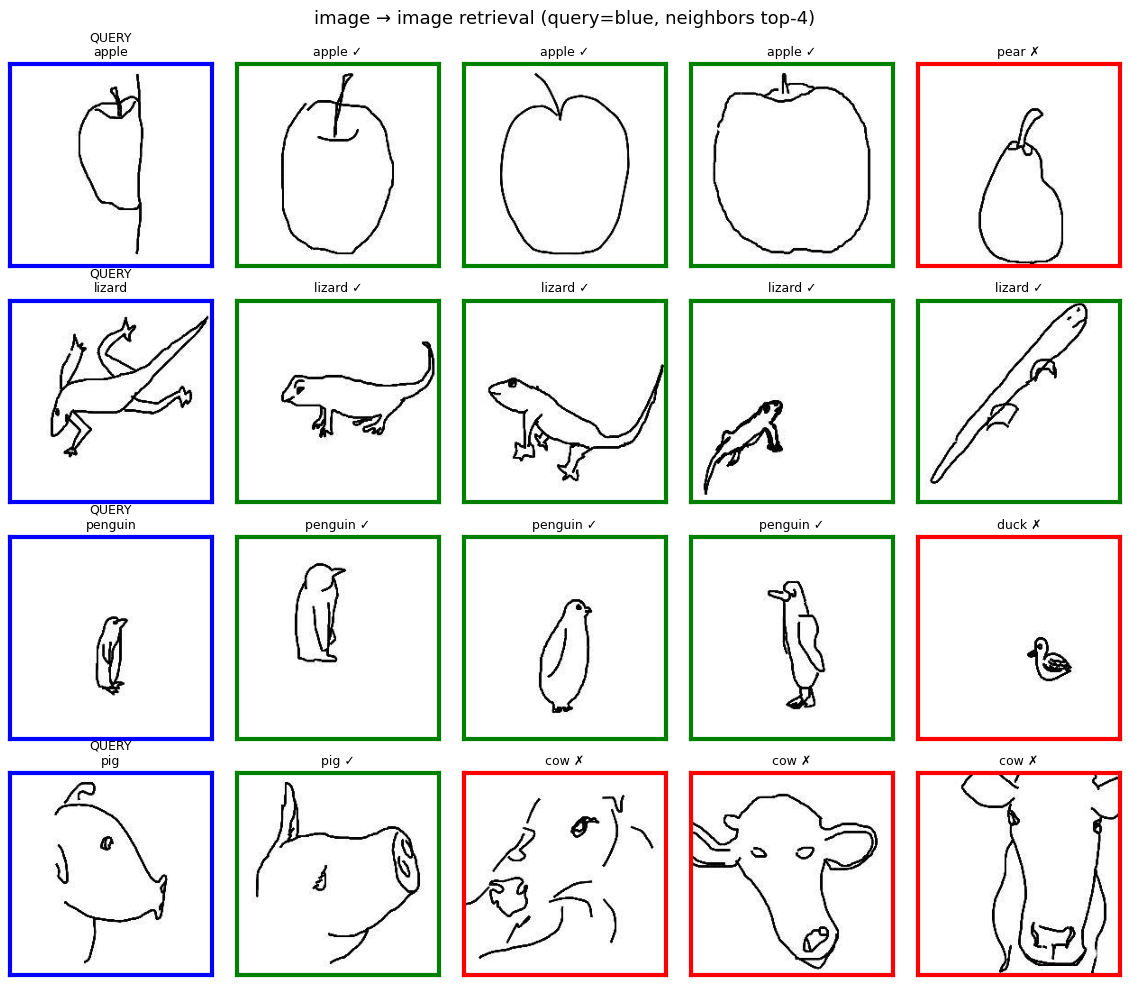

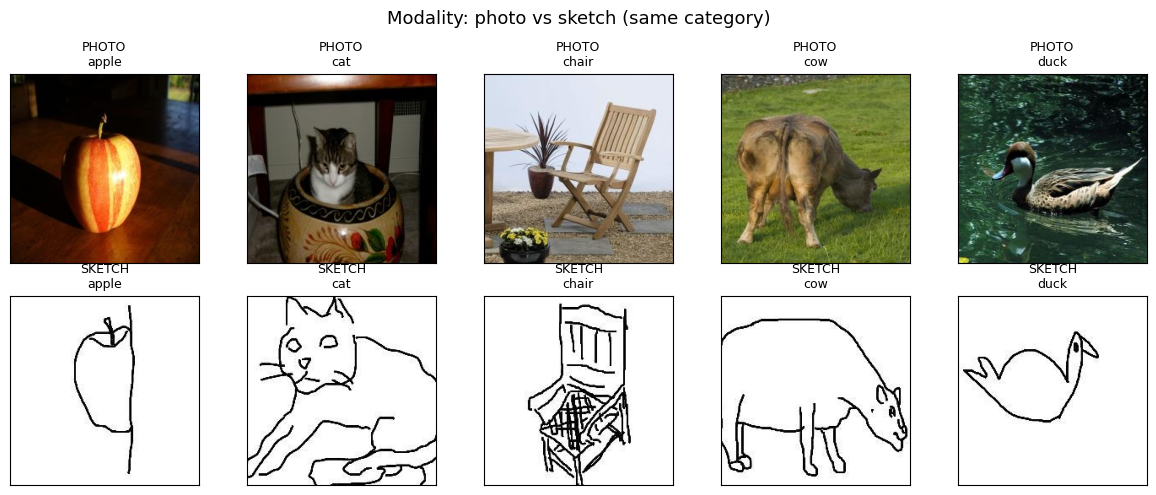

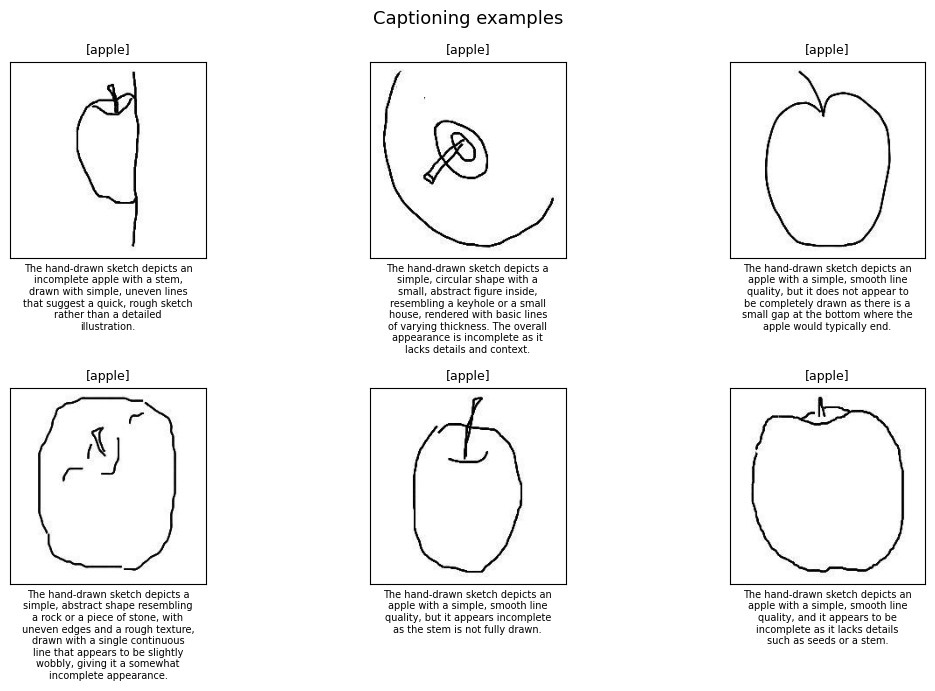

In [11]:
# ============================================================
#  1주차 시각화: 실패 케이스 / 검색 결과 / 모달리티 비교를 이미지 패널로
#  (앞 노트북에서 img_emb, txt_emb, SKETCHES, labels 가 있으면 재사용)
#  런타임: 앞 셀들 실행 후 이어서. 끊겼으면 CELL 0이 재계산.
#  출력: outputs PNG 5장 + 자동 다운로드
# ============================================================


# ====== CELL 0 : 준비 (변수 없으면 재로드/재계산) ======
import os, glob, re, json, textwrap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

def gt_of(f): return os.path.basename(f).split("__")[0].lower()
def load(p): return Image.open(p).convert("RGB")

SK_DIR, PH_DIR = "data_samples/sketchy_sketch", "data_samples/sketchy_photo"
if "SKETCHES" not in globals():
    SKETCHES = sorted(f for f in glob.glob(SK_DIR + "/*") if f.lower().endswith((".jpg", ".png")))
    labels = [gt_of(f) for f in SKETCHES]
    CATS = sorted(set(labels))

# 검색용 임베딩이 없으면 SigLIP2로 재계산
if "img_emb" not in globals() or "txt_emb" not in globals():
    print("임베딩 재계산(SigLIP2)...")
    from transformers import AutoProcessor as SPProc, AutoModel
    SIG = "google/siglip2-base-patch16-224"
    sp = SPProc.from_pretrained(SIG)
    sm = AutoModel.from_pretrained(SIG, torch_dtype=torch.float16).to("cuda").eval()
    def _feat(o):
        if torch.is_tensor(o): return o
        for a in ("image_embeds", "text_embeds", "pooler_output"):
            v = getattr(o, a, None)
            if v is not None: return v
    @torch.no_grad()
    def emb_imgs(paths, bs=16):
        out = []
        for i in range(0, len(paths), bs):
            ims = [load(p) for p in paths[i:i+bs]]
            inp = sp(images=ims, return_tensors="pt").to("cuda")
            e = _feat(sm.get_image_features(**inp)); e = e / e.norm(dim=-1, keepdim=True)
            out.append(e.float().cpu())
        return torch.cat(out)
    @torch.no_grad()
    def emb_txts(ts):
        inp = sp(text=ts, padding="max_length", return_tensors="pt").to("cuda")
        e = _feat(sm.get_text_features(**inp)); return (e / e.norm(dim=-1, keepdim=True)).float().cpu()
    img_emb = emb_imgs(SKETCHES)
    txt_emb = emb_txts([f"a sketch of a {c}" for c in CATS])

os.makedirs("outputs", exist_ok=True)

def panel(ax, img, title, border=None):
    ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9)
    if border:
        for s in ax.spines.values():
            s.set_edgecolor(border); s.set_linewidth(3)


# ====== CELL 1 : 실패 케이스 패널 (GT -> 모델 오답) ======
res = json.load(open("vlm_table_results.json"))["sketch"] if os.path.exists("vlm_table_results.json") else None
if res is None and "sketch_res" in globals(): res = sketch_res

desired_failure_patterns = {
    "cow": ["horse", "goat", "dog", "deer", "mouse"],
    "duck": ["swan", "bird"],
    "hat": ["shoe", "helmet", "purse", "ring", "acorn"],
    "apple": ["satellite dish", "rock"],
}

fails_to_display = []
seen_files = set() # To avoid adding the same file multiple times if it matches multiple patterns

if res is not None:
    for r in res:
        if not r["correct"]:
            gt_lower = r["gt"].lower()
            pred_lower = r["pred"].lower()

            if gt_lower in desired_failure_patterns:
                for desired_pred_part in desired_failure_patterns[gt_lower]:
                    if desired_pred_part in pred_lower and r["file"] not in seen_files:
                        fails_to_display.append(r)
                        seen_files.add(r["file"])
                        break # Move to the next record once a match is found and added
        if len(fails_to_display) >= 12: # Limit the total number of failure cases displayed
            break

fails = fails_to_display
n = len(fails); cols = 4; rows = (n + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(cols*2.6, rows*2.8))
for ax, r in zip(axs.ravel(), fails):
    img = load(os.path.join(SK_DIR, r["file"]))
    panel(ax, img, f"GT: {r['gt']}\n→ pred: {r['pred']}", border="red")
for ax in axs.ravel()[n:]: ax.axis("off")
plt.suptitle("Object abstraction — Failure cases (sketch)", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/fig_failures.png", dpi=130, bbox_inches="tight"); plt.show()


# ====== CELL 2 : text -> image 검색 결과 (쿼리별 top-5) ======
sim = txt_emb @ img_emb.T
queries = ["cow", "hat", "horse", "duck"]            # 보여줄 쿼리 카테고리
queries = [q for q in queries if q in CATS][:4]
fig, axs = plt.subplots(len(queries), 5, figsize=(5*2.3, len(queries)*2.5))
for qi, q in enumerate(queries):
    ci = CATS.index(q)
    top5 = sim[ci].topk(5).indices.tolist()
    for j, idx in enumerate(top5):
        ok = labels[idx] == q
        ttl = f"{labels[idx]}" + (" ✓" if ok else " ✗")
        panel(axs[qi][j], load(SKETCHES[idx]), ttl, border="green" if ok else "red")
    axs[qi][0].set_ylabel(f"query:\n'{q}'", fontsize=11, rotation=0, labelpad=30, va="center")
plt.suptitle("text → image retrieval (top-5, green=correct)", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/fig_retrieval_t2i.png", dpi=130, bbox_inches="tight"); plt.show()


# ====== CELL 3 : image -> image 검색 (쿼리 + 최근접 4개) ======
isim = (img_emb @ img_emb.T).clone(); isim.fill_diagonal_(-1)
# 카테고리 다양하게 쿼리 4장 선택
query_categories = ['apple', 'penguin', 'lizard', 'pig'] # New query categories
qidx = []
for i, lb in enumerate(labels):
    if lb in query_categories and lb not in [labels[j] for j in qidx]:
        qidx.append(i)
    if len(qidx) == len(query_categories): break

fig, axs = plt.subplots(len(qidx), 5, figsize=(5*2.3, len(qidx)*2.5))
for r, qi in enumerate(qidx):
    panel(axs[r][0], load(SKETCHES[qi]), f"QUERY\n{labels[qi]}", border="blue")
    nn = isim[qi].topk(4).indices.tolist()
    for j, idx in enumerate(nn):
        ok = labels[idx] == labels[qi]
        panel(axs[r][j+1], load(SKETCHES[idx]), f"{labels[idx]}" + (" ✓" if ok else " ✗"),
              border="green" if ok else "red")
plt.suptitle("image → image retrieval (query=blue, neighbors top-4)", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/fig_retrieval_i2i.png", dpi=130, bbox_inches="tight"); plt.show()


# ====== CELL 4 : 모달리티 비교 (사진 vs 스케치, 같은 카테고리) ======
pairs = []
for c in CATS:
    ph = sorted(glob.glob(f"{PH_DIR}/{c}__*", recursive=True)); sk = sorted(glob.glob(f"{SK_DIR}/{c}__*", recursive=True))
    if ph and sk: pairs.append((c, ph[0], sk[0]))
    if len(pairs) == 5: break
fig, axs = plt.subplots(2, len(pairs), figsize=(len(pairs)*2.4, 5))
for j, (c, ph, sk) in enumerate(pairs):
    panel(axs[0][j], load(ph), f"PHOTO\n{c}")
    panel(axs[1][j], load(sk), f"SKETCH\n{c}")
plt.suptitle("Modality: photo vs sketch (same category)", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/fig_modality.png", dpi=130, bbox_inches="tight"); plt.show()


# ====== CELL 5 : 캡셔닝 예시 (이미지 + 생성 캡션) ======
caps = json.load(open("task1_captioning.json")) if os.path.exists("task1_captioning.json") else cap_results
pick = caps[:6]
fig, axs = plt.subplots(2, 3, figsize=(11, 7))
for ax, r in zip(axs.ravel(), pick):
    img = load(os.path.join(SK_DIR, r["file"]))
    cap = "\n".join(textwrap.wrap(r["caption"], 34))
    panel(ax, img, f"[{r['gt']}]")
    ax.set_xlabel(cap, fontsize=7)
plt.suptitle("Captioning examples", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/fig_captioning.png", dpi=130, bbox_inches="tight"); plt.show()
